# Demo for reducing the Euclid flagship simulations:

The full simulations are available at https://cosmohub.pic.es/catalogs/353. If you use the catalog for any publication, please use the acknowledgements listed on this website.

Notice that the catalog inherently has a cut for the Euclid h band at ${\tt euclid\_nisp\_h} < 26.6$, although there is a small region (150 < RA < 155 deg., 5 < DEC < 10 deg.) where there is no magnitude or flux cut, which has significantly higher number density. The full catalog covers 1 octant of the sky, and the example files are randomly chosen rectanglar 'tracts' over the footprint, complete to $i=27$.

To cover the LSST footprint, an easy operation is to flip the sign of the `dec` and add 180 deg to the `ra`. This is done through the reducer.

In [1]:
# import relevant packages
import os
from rail.projects import library
from rail.projects import RailProject

check_dir = os.path.basename(os.path.abspath(os.curdir))
if check_dir == 'examples':
    os.chdir('..')

#setup = library.setup_project_area()
#assert setup == 0

# use this to cleanup
#library.teardown_project_area()

We load the project configuration for flagship below. 

The config file, `flagship_project.yaml`, is very similar to the RomanRubin example, but you notice a few difference. 
Firstly, I changed the `CommonPaths` to the path to the flagship example catalog. I changed the `catalog_tag` under `Baseline` to `flagship` as well. Finally, I changed `IterationVars` to match the iteration pattern. 

I also changed the file naming patterns in a new project library file, `flagship_project_libraray.yaml`.  

In [2]:
# load the project configuration:
project_flagship = RailProject.load_config("examples/flagship_project.yaml")

We can check if we've found the catalog we specified:

In [3]:
catalog_files_truth = project_flagship.get_catalog_files("truth")
list(catalog_files_truth)

['/global/cfs/cdirs/lsst/groups/PZ/Flagship/euclid_fs2_mock_dr_v1_1_phz.pix5.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/euclid_fs2_mock_dr_v1_1_phz.pix10.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/euclid_fs2_mock_dr_v1_1_phz.pix20.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/euclid_fs2_mock_dr_v1_1_phz.pix21.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/euclid_fs2_mock_dr_v1_1_phz.pix22.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/euclid_fs2_mock_dr_v1_1_phz.pix25.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/euclid_fs2_mock_dr_v1_1_phz.pix28.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/euclid_fs2_mock_dr_v1_1_phz.pix29.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/euclid_fs2_mock_dr_v1_1_phz.pix30.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/euclid_fs2_mock_dr_v1_1_phz.pix32.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/euclid_fs2_mock_dr_v1_1_phz.pix47.pq']

Yes, this is the correct directory. Now we can reduce the raw catalog to the correct format we want.
To do this, we simply changed the `reducer_class_name` to `flagship`. This is defined in the library file, and calls the `FlagshipReducer`. This reducer does the following things:
- Convert all fluxes (here, we use columns `[fluxtype]_el_model3_ext` which includes fluxes from both the continuum and the emission lines from the galaxy, and `[fluxtype]` denotes LSST $ugrizy$ and Euclid nisp y,j,h and Euclid vis) into magnitudes, and rename the columns to standard values.
- Compute the semi-major and minor axes of the galaxy in arcsec and save in the `major` and `minor` columns. Some intermediate quantites such as orientation angles are also saved.
- Apply a `gold` magnitude cut, also defined in the library, which corresponds to $i<25.5$. 

Note this has been run in the shared PZ directory - you don't have to re-run the cell below.

In [4]:
project_flagship.reduce_data(
    catalog_template="truth",
    output_catalog_template="reduced",
    reducer_class_name="flagship",
    input_selection="",
    selection="gold",
)

writing dataset to /global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/5/euclid_fs2_mock_dr_v1_1_phz.pq
writing dataset to /global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/10/euclid_fs2_mock_dr_v1_1_phz.pq
writing dataset to /global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/20/euclid_fs2_mock_dr_v1_1_phz.pq
writing dataset to /global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/21/euclid_fs2_mock_dr_v1_1_phz.pq
writing dataset to /global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/22/euclid_fs2_mock_dr_v1_1_phz.pq
writing dataset to /global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/25/euclid_fs2_mock_dr_v1_1_phz.pq
writing dataset to /global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/28/euclid_fs2_mock_dr_v1_1_phz.pq
writing dataset to /global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/29/euclid_fs2_mock_dr_v1_1_phz.pq
writing dataset to /global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/30/euclid

['/global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/5/euclid_fs2_mock_dr_v1_1_phz.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/10/euclid_fs2_mock_dr_v1_1_phz.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/20/euclid_fs2_mock_dr_v1_1_phz.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/21/euclid_fs2_mock_dr_v1_1_phz.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/22/euclid_fs2_mock_dr_v1_1_phz.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/25/euclid_fs2_mock_dr_v1_1_phz.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/28/euclid_fs2_mock_dr_v1_1_phz.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/29/euclid_fs2_mock_dr_v1_1_phz.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/30/euclid_fs2_mock_dr_v1_1_phz.pq',
 '/global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/32/euclid_fs2_mock_dr_v1_1_phz.pq',
 '/global/c

You can check the input and output catalogs, to see if the reducer has worked. You see some additional columns:
- `ra`, `dec` are the rotated sky coordinates from the original positions, `ra_mag_gal` and `dec_mag_gal`
- `redshift` is the a re-naming of `observed_redshift_gal` (would like to remove duplication in future versions)
- `mag_{band}_lsst` are the LSST magnitudes converted from the fluxes `lsst_{band}_el_model3_ext`. Similarly for the Euclid bands
- A bunch of galaxy size information: `totalHalfLightRadiusArcsec`, `_orientationAngle`, `major`, `minor`, `orientationAngle` derived from relevant columns in the original catalogue (would like to remove duplication in future versions)

In [5]:
import tables_io

In [6]:
fname = '/global/cfs/cdirs/lsst/groups/PZ/Flagship/test_flagship_gold/5/euclid_fs2_mock_dr_v1_1_phz.pq'
goldtab = tables_io.read(fname)
golddf = tables_io.convert(goldtab, tables_io.types.PD_DATAFRAME)
golddf.info()

column_list None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22429427 entries, 0 to 22429426
Data columns (total 40 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   halo_id                      int64  
 1   galaxy_id                    int64  
 2   observed_redshift_gal        float32
 3   ra_mag_gal                   float32
 4   dec_mag_gal                  float32
 5   lsst_u_el_model3_ext         float32
 6   lsst_g_el_model3_ext         float32
 7   lsst_r_el_model3_ext         float32
 8   lsst_i_el_model3_ext         float32
 9   lsst_z_el_model3_ext         float32
 10  lsst_y_el_model3_ext         float32
 11  euclid_nisp_h_el_model3_ext  float32
 12  euclid_nisp_j_el_model3_ext  float32
 13  euclid_nisp_y_el_model3_ext  float32
 14  euclid_vis_el_model3_ext     float32
 15  bulge_r50                    float32
 16  disk_r50                     float32
 17  bulge_fraction               float32
 18  gamma1                 

### Subsample the test project

This will use the "random_subsampler" to apply the "train_10" subsample to the "reduced" catalog of the baseline flavor with the gold selection

In [7]:
project_flagship.subsample_data(
    catalog_template="reduced",
    file_template="train_file_200k",
    subsampler_class_name="random_subsampler",
    subsample_name="train_200k",
    flavor="baseline",
    selection="gold",
)

num rows 218233798
sampling 200000
writing /global/cfs/cdirs/lsst/groups/PZ/Flagship/test/test_flagship_gold_baseline_200k.parquet
done


'/global/cfs/cdirs/lsst/groups/PZ/Flagship/test/test_flagship_gold_baseline_200k.parquet'

Now let's check out the subsampled results:

In [8]:
goldfile = "/global/cfs/cdirs/lsst/groups/PZ/Flagship/test/test_flagship_gold_baseline_200k.parquet"
goldtab = tables_io.read(goldfile)
golddf = tables_io.convert(goldtab, tables_io.types.PD_DATAFRAME)
golddf.info()

column_list None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 40 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   halo_id                      200000 non-null  int64  
 1   galaxy_id                    200000 non-null  int64  
 2   observed_redshift_gal        200000 non-null  float32
 3   ra_mag_gal                   200000 non-null  float32
 4   dec_mag_gal                  200000 non-null  float32
 5   lsst_u_el_model3_ext         200000 non-null  float32
 6   lsst_g_el_model3_ext         200000 non-null  float32
 7   lsst_r_el_model3_ext         200000 non-null  float32
 8   lsst_i_el_model3_ext         200000 non-null  float32
 9   lsst_z_el_model3_ext         200000 non-null  float32
 10  lsst_y_el_model3_ext         200000 non-null  float32
 11  euclid_nisp_h_el_model3_ext  200000 non-null  float32
 12  euclid_nisp_j_el_model3_ext  200000 non-n

In [9]:
import matplotlib.pyplot as plt

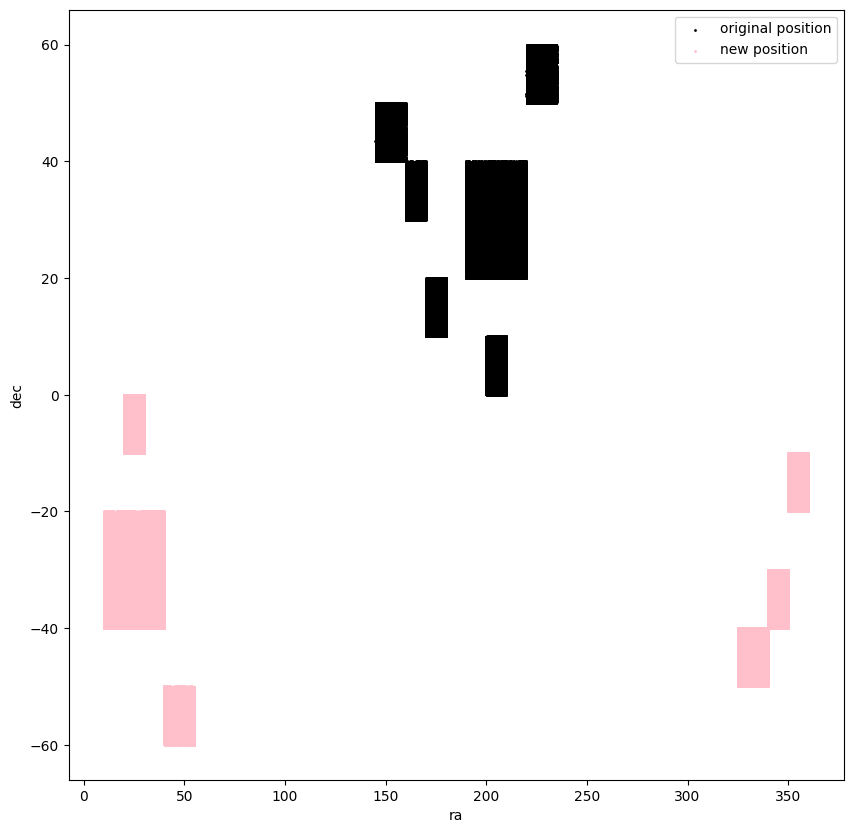

In [16]:
plt.figure(figsize=(10,10))

plt.scatter(golddf['ra_mag_gal'], golddf['dec_mag_gal'], s=1, c='k', label="original position")
plt.xlabel("ra")
plt.ylabel("dec")
#plt.title("Original positions")

plt.scatter(golddf['ra'], golddf['dec'], s=1, c='pink', label="new position")
#plt.xlabel("ra")
#plt.ylabel("dec")
#plt.title("New positions")
plt.legend()

In [17]:
gr = golddf['mag_g_lsst'] - golddf['mag_r_lsst']

(-0.5, 4.5)

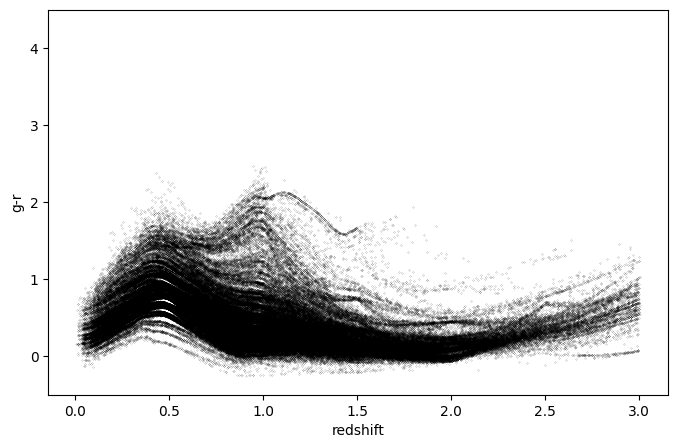

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(golddf['observed_redshift_gal'], gr, s=0.01,c='k')
plt.xlabel("redshift")
plt.ylabel("g-r")
plt.ylim([-0.5,4.5])

Text(0, 0.5, 'Number')

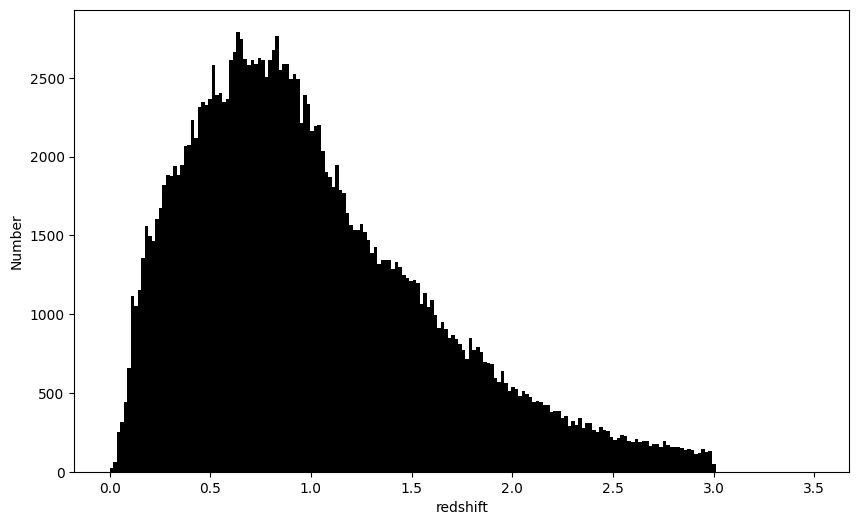

In [19]:
# plot the redshift distribution of the "gold" i<25.5 sample:
import numpy as np
plt.figure(figsize=(10,6))
plt.hist(golddf['observed_redshift_gal'], bins=np.linspace(0,3.5,201), color='k');
plt.xlabel("redshift")
plt.ylabel("Number")